#### Чекпоинт 6

Для начала зафиксируем разбиение, чтобы корректно сравнивать результат нейросетей

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pickle

df_train = pd.read_csv('/Users/anastasia/Downloads/train_with_new_features.csv')
df_test  = pd.read_csv('/Users/anastasia/Downloads/test_with_new_features.csv')

df_train = df_train.drop(columns=['id', 'address', 'address_rus'], errors='ignore')
df_test  = df_test.drop(columns=['Unnamed: 0', 'id', 'address', 'address_rus'], errors='ignore')

df_train = df_train.dropna()
df_test  = df_test.dropna()

X_train_full = df_train.drop(columns=['target'])
y_train_full = df_train['target']

X_test = df_test.drop(columns=['target'])
y_test = df_test['target']

if 'population' in X_train_full.columns:
    X_train_full['population'] = X_train_full['population'].astype(str).str.replace("\xa0", "", regex=False).astype(float)
    X_test['population']       = X_test['population'].astype(str).str.replace("\xa0", "", regex=False).astype(float)

if 'atm_group' in X_train_full.columns:
    X_train_full['atm_group'] = X_train_full['atm_group'].astype(float)
    X_test['atm_group']       = X_test['atm_group'].astype(float)

object_cols = X_train_full.select_dtypes(include='object').columns
for col in object_cols:
    X_train_full[col] = pd.to_numeric(X_train_full[col], errors='coerce')
    X_test[col]       = pd.to_numeric(X_test[col], errors='coerce')

feature_names = X_train_full.columns.tolist()
np.save('feature_names.npy', np.array(feature_names))
with open('feature_names.txt', 'w') as f:
    f.write('\n'.join(feature_names))

X_test = X_test[feature_names]

imputer = SimpleImputer(strategy='median')
X_train_full_np = imputer.fit_transform(X_train_full.values)
X_test_np       = imputer.transform(X_test.values)

X_train_np, X_val_np, y_train, y_val = train_test_split(
    X_train_full_np, y_train_full,
    test_size=0.2,
    random_state=42,
    shuffle=True
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_val_scaled   = scaler.transform(X_val_np)
X_test_scaled  = scaler.transform(X_test_np)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
X_val_scaled   = np.nan_to_num(X_val_scaled, nan=0.0)
X_test_scaled  = np.nan_to_num(X_test_scaled, nan=0.0)

np.savez('fixed_splits_new.npz',
         X_train=X_train_scaled,
         X_val=X_val_scaled,
         X_test=X_test_scaled,
         y_train=y_train.values if hasattr(y_train, 'values') else y_train,
         y_val=y_val.values if hasattr(y_val, 'values') else y_val,
         y_test=y_test.values if hasattr(y_test, 'values') else y_test,
         feature_names=np.array(feature_names))

with open('scaler_new.pkl', 'wb') as f:
    pickle.dump(scaler, f)

Device: mps
Features: 18

=== MLP_basic ===
  Epoch  10: train MSE 0.0062, val MSE 0.0038
  Epoch  20: train MSE 0.0039, val MSE 0.0031
  Epoch  30: train MSE 0.0035, val MSE 0.0030
  Epoch  40: train MSE 0.0033, val MSE 0.0028
  Epoch  50: train MSE 0.0032, val MSE 0.0027
  Epoch  60: train MSE 0.0032, val MSE 0.0028
  Epoch  70: train MSE 0.0031, val MSE 0.0027
  Epoch  80: train MSE 0.0030, val MSE 0.0027
  Epoch  90: train MSE 0.0029, val MSE 0.0027
  Epoch 100: train MSE 0.0030, val MSE 0.0027

=== MLP_deep6 ===
  Epoch  10: train MSE 0.0143, val MSE 0.0073
  Epoch  20: train MSE 0.0068, val MSE 0.0051
  Epoch  30: train MSE 0.0052, val MSE 0.0040
  Epoch  40: train MSE 0.0045, val MSE 0.0036
  Epoch  50: train MSE 0.0041, val MSE 0.0033
  Epoch  60: train MSE 0.0038, val MSE 0.0032
  Epoch  70: train MSE 0.0037, val MSE 0.0031
  Epoch  80: train MSE 0.0035, val MSE 0.0031
  Epoch  90: train MSE 0.0034, val MSE 0.0030
  Epoch 100: train MSE 0.0033, val MSE 0.0031

=== ResNet2 ===


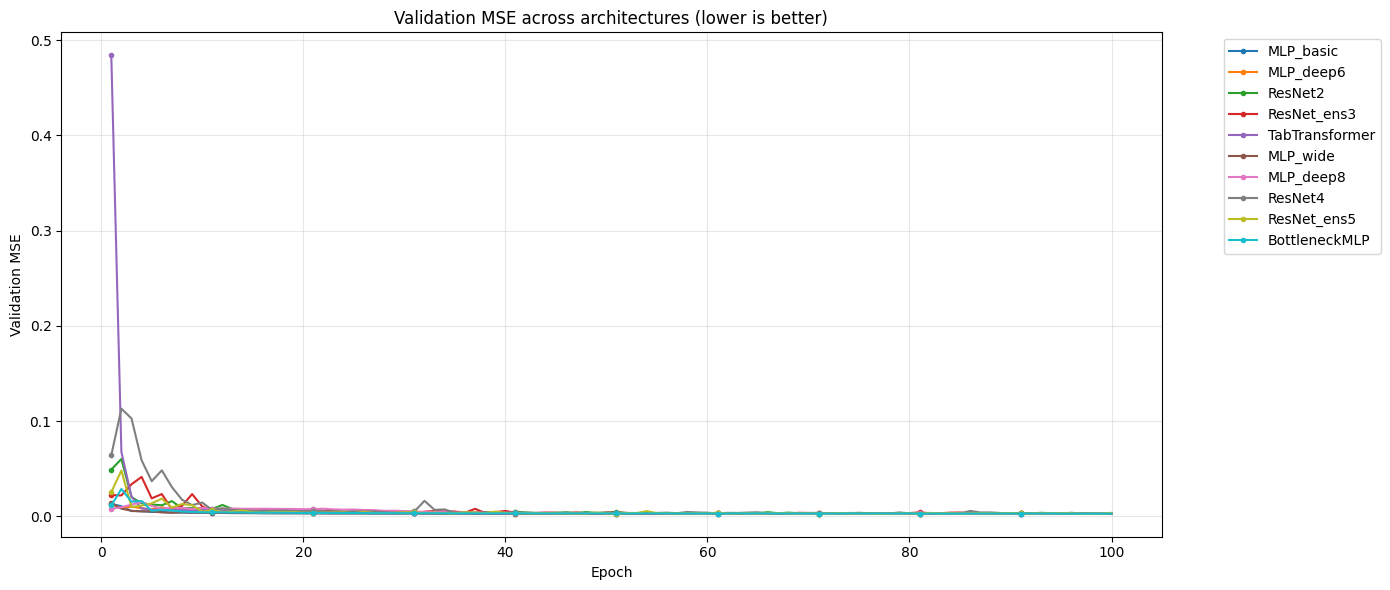

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import time

data = np.load('fixed_splits_new.npz')
X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']

device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
print(f'Device: {device}\nFeatures: {X_train.shape[1]}')

train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_dataset   = TensorDataset(torch.FloatTensor(X_val),   torch.FloatTensor(y_val))
test_dataset  = TensorDataset(torch.FloatTensor(X_test),  torch.FloatTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,
                          generator=torch.Generator().manual_seed(42))
val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

input_size = X_train.shape[1]

def train_model(model, optimizer, criterion, train_loader, val_loader, epochs=100, verbose=False):
    model = model.to(device)
    train_loss, val_loss, train_mse, val_mse = [], [], [], []

    for epoch in range(1, epochs+1):
        # Train
        model.train()
        rloss, rmse = 0.0, 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            rloss += loss.item() * Xb.size(0)
            rmse += mean_squared_error(yb.cpu(), pred.detach().cpu()) * Xb.size(0)
        train_loss.append(rloss / len(train_loader.dataset))
        train_mse.append(rmse / len(train_loader.dataset))

        model.eval()
        rloss, rmse = 0.0, 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                pred = model(Xb)
                loss = criterion(pred, yb)
                rloss += loss.item() * Xb.size(0)
                rmse += mean_squared_error(yb.cpu(), pred.cpu()) * Xb.size(0)
        val_loss.append(rloss / len(val_loader.dataset))
        val_mse.append(rmse / len(val_loader.dataset))

        if verbose and epoch % 10 == 0:
            print(f'  Epoch {epoch:3d}: train MSE {train_mse[-1]:.4f}, val MSE {val_mse[-1]:.4f}')
    return train_loss, val_loss, train_mse, val_mse

def test_model(model):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            pred = model(Xb)
            preds.append(pred.cpu().numpy())
            trues.append(yb.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = mean_squared_error(trues, preds)
    return mse, np.sqrt(mse)

class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden=[256, 128], dropout=0.3):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

class DeepMLP(nn.Module):
    def __init__(self, input_size, hidden=[128]*6, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.net(x) + x)

class ATMNet(nn.Module):
    def __init__(self, input_size, hidden=256, dropout=0.3, num_blocks=2):
        super().__init__()
        self.input_layer = nn.Sequential(nn.Linear(input_size, hidden), nn.BatchNorm1d(hidden), nn.ReLU())
        self.blocks = nn.Sequential(*[ResidualBlock(hidden, dropout) for _ in range(num_blocks)])
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        x = self.input_layer(x)
        x = self.blocks(x)
        return self.head(x).squeeze(-1)

class ResidualEnsemble(nn.Module):
    def __init__(self, input_size, hidden=256, dropout=0.3, num_models=3):
        super().__init__()
        self.models = nn.ModuleList([ATMNet(input_size, hidden, dropout) for _ in range(num_models)])
    def forward(self, x):
        return torch.stack([m(x) for m in self.models], dim=0).mean(dim=0)

class TabTransformer(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        assert d_model % nhead == 0, "d_model must be divisible by nhead"
        self.feature_embed = nn.ModuleList([nn.Linear(1, d_model) for _ in range(input_size)])
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(input_size * d_model, 1)
    def forward(self, x):
        embeds = [layer(x[:, i:i+1]) for i, layer in enumerate(self.feature_embed)]
        x = torch.stack(embeds, dim=1)
        x = self.transformer(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x).squeeze(-1)

class BottleneckMLP(nn.Module):
    def __init__(self, input_size, hidden=[512, 256, 64, 256, 128], dropout=0.3):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

architectures = {
    'MLP_basic':         SimpleMLP(input_size, hidden=[256, 128], dropout=0.3),
    'MLP_deep6':         DeepMLP(input_size, hidden=[128]*6, dropout=0.3),
    'ResNet2':           ATMNet(input_size, hidden=256, dropout=0.3, num_blocks=2),
    'ResNet_ens3':       ResidualEnsemble(input_size, hidden=256, dropout=0.3, num_models=3),
    'TabTransformer':    TabTransformer(input_size, d_model=64, nhead=4, num_layers=2, dropout=0.2),
    'MLP_wide':          SimpleMLP(input_size, hidden=[512, 256, 128], dropout=0.3),
    'MLP_deep8':         DeepMLP(input_size, hidden=[128]*8, dropout=0.3),
    'ResNet4':           ATMNet(input_size, hidden=256, dropout=0.3, num_blocks=4),
    'ResNet_ens5':       ResidualEnsemble(input_size, hidden=256, dropout=0.3, num_models=5),
    'BottleneckMLP':     BottleneckMLP(input_size, hidden=[512, 256, 64, 256, 128], dropout=0.3),
}

results = {}
history = {}
epochs = 100

for name, model in architectures.items():
    print(f'\n=== {name} ===')
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    crit = nn.MSELoss()
    start = time.time()
    tl, vl, tm, vm = train_model(model, opt, crit, train_loader, val_loader,
                                 epochs=epochs, verbose=True)
    elapsed = time.time() - start
    test_mse, test_rmse = test_model(model)
    results[name] = {
        'best_val_mse': min(vm),
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'time_sec': int(elapsed)
    }
    history[name] = {'train_mse': tm, 'val_mse': vm}

res_df = pd.DataFrame(results).T
res_df = res_df.round(4)
res_df.sort_values('best_val_mse', inplace=True)

print('\n' + '='*60)
print('Сравнение архитектур (сортировка по val MSE)')
print('='*60)
print(res_df)

best_name = res_df.index[0]
print(f'\nЛучшая модель по val MSE: {best_name}')
print(f'Test RMSE этой модели: {res_df.loc[best_name, "test_rmse"]:.4f}')


res_df.to_csv('model_comparison.csv')
print('\nТаблицу сохранили в model_comparison.csv')

plt.figure(figsize=(14, 6))
for name in architectures:
    plt.plot(range(1, len(history[name]['val_mse'])+1),
             history[name]['val_mse'], label=name, marker='.', markevery=10)
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.title('Validation MSE across architectures (lower is better)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1) Таким образом, лучший результат показала MLP_wide. Для данной задачи не нужны сложные архитектуры. 

2) MLP_basic чуть хуже MLP_wide, но разница незначительна. Ширина помогла

3) Слишком большая глубина без Residual-связей приводит к деградации градиента и переобучению

4) Tabtransformer - его кривая шла выше остальных почти всё обучение и лишь к концу приблизилась. На малых табличных данных склонны к переобучению

5) BottleneckMLP - сжатие признаков и обратное расширение не помогло. Потерялась информация, а число параметров осталось большим. «Бутылочное горлышко» не дало эффекта, потому что входных признаков и так мало

Вывод: оптимально иметь 1–2 скрытых слоя. Дает наилучшее качество и требует меньше всего времени на инференс. 

Прогоним на текущих данных ResidualEnsemble, который мы делали для прошлого чекпоинта

In [ ]:
data = np.load('fixed_splits_new.npz')
X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_dataset   = TensorDataset(torch.FloatTensor(X_val),   torch.FloatTensor(y_val))
test_dataset  = TensorDataset(torch.FloatTensor(X_test),  torch.FloatTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,
                          generator=torch.Generator().manual_seed(42))
val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

input_size = X_train.shape[1]

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.fc(x) + x)

class ATMNet(nn.Module):
    def __init__(self, input_size, hidden_size=256, dropout=0.3):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )
        self.res_block1 = ResidualBlock(256, dropout)
        self.res_block2 = ResidualBlock(256, dropout)
        self.output = nn.Linear(256, 1)
    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        return self.output(x).squeeze(-1)

class ResidualEnsemble(nn.Module):
    def __init__(self, input_size, n_models=3, hidden_size=256, dropout=0.3):
        super().__init__()
        self.models = nn.ModuleList([
            ATMNet(input_size, hidden_size, dropout) for _ in range(n_models)
        ])
    def forward(self, x):
        preds = [model(x) for model in self.models]
        return torch.stack(preds, dim=0).mean(dim=0)

def train_model(model, optimizer, criterion, train_loader, val_loader, epochs=100, verbose=False):
    model = model.to(device)
    train_mse, val_mse = [], []
    for epoch in range(1, epochs+1):
        model.train()
        rloss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            rloss += loss.item() * Xb.size(0)
        train_mse.append(rloss / len(train_loader.dataset))

        model.eval()
        rloss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                pred = model(Xb)
                loss = criterion(pred, yb)
                rloss += loss.item() * Xb.size(0)
        val_mse.append(rloss / len(val_loader.dataset))

        if verbose and epoch % 10 == 0:
            print(f'  Epoch {epoch:3d}: train loss {train_mse[-1]:.4f}, val loss {val_mse[-1]:.4f}')
    return train_mse, val_mse

def test_model(model):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            pred = model(Xb)
            preds.append(pred.cpu().numpy())
            trues.append(yb.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = mean_squared_error(trues, preds)
    return mse, np.sqrt(mse)

torch.manual_seed(42)
model_old_ens = ResidualEnsemble(input_size, n_models=3, hidden_size=256, dropout=0.3)
opt = torch.optim.Adam(model_old_ens.parameters(), lr=0.001)
crit = nn.MSELoss()
start = time.time()
train_loss, val_loss = train_model(model_old_ens, opt, crit, train_loader, val_loader, epochs=100, verbose=True)
train_time = time.time() - start
test_mse, test_rmse = test_model(model_old_ens)

print(f'\nСтарый Residual Ensemble:')
print(f'  Лучшая val MSE: {min(val_loss):.4f}')
print(f'  Test MSE: {test_mse:.4f}')
print(f'  Test RMSE: {test_rmse:.4f}')

Device: mps
  Epoch  10: train loss 0.0118, val loss 0.0073
  Epoch  20: train loss 0.0058, val loss 0.0066
  Epoch  30: train loss 0.0038, val loss 0.0035
  Epoch  40: train loss 0.0031, val loss 0.0031
  Epoch  50: train loss 0.0029, val loss 0.0038
  Epoch  60: train loss 0.0026, val loss 0.0035
  Epoch  70: train loss 0.0023, val loss 0.0029
  Epoch  80: train loss 0.0021, val loss 0.0030
  Epoch  90: train loss 0.0020, val loss 0.0030
  Epoch 100: train loss 0.0021, val loss 0.0031

Старый Residual Ensemble:
  Лучшая val MSE: 0.0029
  Test MSE: 0.0017
  Test RMSE: 0.0408
  Время обучения: 20 сек


In [23]:
import pickle
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

data = np.load('fixed_splits_new.npz')
X_train_scaled = data['X_train']
X_val_scaled   = data['X_val']
X_test_scaled  = data['X_test']
y_train = data['y_train']
y_val   = data['y_val']
y_test  = data['y_test']

with open('scaler_new.pkl', 'rb') as f:
    scaler = pickle.load(f)

X_train_raw = scaler.inverse_transform(X_train_scaled)
X_val_raw   = scaler.inverse_transform(X_val_scaled)
X_test_raw  = scaler.inverse_transform(X_test_scaled)

model_lgb = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbose=-1
)
model_lgb.fit(
    X_train_raw, y_train,
    eval_set=[(X_val_raw, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)
preds_test = model_lgb.predict(X_test_raw)
rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
mse_test = mean_squared_error(y_test, preds_test)

print(f'Gradient Boosting (LightGBM) Test RMSE: {rmse_test:.4f}')
print(f'Gradient Boosting (LightGBM) Test MSE: {mse_test:.4f}')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[390]	valid_0's l2: 0.00205617
Gradient Boosting (LightGBM) Test RMSE: 0.0207
Gradient Boosting (LightGBM) Test MSE: 0.0004


/Users/anastasia/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [22]:
res_df = pd.DataFrame(results).T 

legacy_result = {
    'best_val_mse': 0.0029,
    'test_mse': 0.0017,
    'test_rmse': 0.0408,
    'time_sec': 20
}

res_df.loc['GradientBoosting'] = {
    'best_val_mse': np.nan,
    'test_mse': 0.0004,
    'test_rmse': 0.0207,
    'time_sec': 1.1
}
res_df = res_df.sort_values('test_rmse')
print(res_df)

res_df.loc['Legacy_ResNet_ens3'] = legacy_result

res_df = res_df.round(4)
res_df = res_df.sort_values('test_rmse')

print('\n' + '='*70)
print('Итоговая сводная таблица (сортировка по Test RMSE)')
print('='*70)
print(res_df)

                  best_val_mse  test_mse  test_rmse  time_sec
GradientBoosting           NaN  0.000400   0.020700       1.1
TabTransformer        0.002671  0.000534   0.023118      62.0
MLP_basic             0.002652  0.000624   0.024989       8.0
MLP_wide              0.002631  0.000672   0.025933      10.0
BottleneckMLP         0.002770  0.000720   0.026828      12.0
MLP_deep6             0.002890  0.000853   0.029213      13.0
MLP_deep8             0.002965  0.000881   0.029690      16.0
ResNet4               0.002804  0.001159   0.034048      18.0
ResNet_ens3           0.002814  0.001332   0.036500      22.0
ResNet2               0.002784  0.001351   0.036753      12.0
ResNet_ens5           0.002690  0.002513   0.050128      34.0

Итоговая сводная таблица (сортировка по Test RMSE)
                    best_val_mse  test_mse  test_rmse  time_sec
GradientBoosting             NaN    0.0004     0.0207       1.1
TabTransformer            0.0027    0.0005     0.0231      62.0
MLP_basic   

Видим, что на отложенной выборке самый лучший результат у TabTransformer. Вывод - нельзя судить о лучшей модели только по валидации. Но TabTransformer все еще имеет худший результат чем градиентный бустинг

Градиентный бустинг. Ппоказывает наименьший  RMSE = 0.0207 и обучается практически мгновенно. На табличных данных малой размерности деревья решений с градиентным бустингом остаются наиболее эффективным методом.

TabTransformer — лучшая нейросеть. Среди всех опробованных нейросетевых архитектур наилучшее качество дал TabTransformer. Модель смогла выучить полезные взаимодействия признаков благодаря аккуратной настройке. Однако проигрыш градиентному бустингу по RMSE составляет около 11%, а время обучения в 50 раз больше.

MLP_basic и MLP_wide практически не уступают TabTransformer, но обучаются на порядок быстрее.

Глубокие plain-MLP ухудшают результат из-за затухания градиентов и начала переобучения.
Добавление остаточных связей (ResNet) не помогло: модели с 2 и 4 блоками, а также их ансамбли, показали значительный рост ошибки. Причина — избыточное число параметров для 18 признаков, что ведёт к переобучению.